# Segmentación Semántica con U-Net y Transfer Learning

En el workshop anterior adaptamos una CNN preentrenada para clasificar imágenes completas — una etiqueta por imagen. Ahora el problema es diferente: queremos asignar una etiqueta a **cada píxel** de la imagen. Esto se conoce como **segmentación semántica**.

Las aplicaciones en imágenes médicas son directas: delimitar un tumor en una resonancia, segmentar un nódulo pulmonar en un TAC, o separar tejido sano de tejido afectado. La precisión a nivel de píxel es exactamente lo que se necesita para medir volúmenes, planificar radioterapia o asistir en el diagnóstico.

La arquitectura de referencia para esta tarea es **U-Net** (Ronneberger et al., 2015), diseñada originalmente para imágenes biomédicas. En este notebook:

1. Entenderemos la arquitectura encoder–decoder con skip connections
2. Construiremos los bloques de U-Net en PyTorch
3. Reemplazaremos el encoder por un ResNet-18 preentrenado
4. Entrenaremos y evaluaremos con métricas de segmentación (IoU, Dice)


## 0. Imports y configuración


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torchvision.models as models

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image
import os, random

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Usando device: {device}')


Usando device: cuda


## 1. Dataset: Oxford-IIIT Pet con máscaras de segmentación

Usaremos el dataset **Oxford-IIIT Pet**, que incluye imágenes de 37 razas de mascotas junto con máscaras de segmentación pixel-wise. Cada píxel tiene una de tres etiquetas:

| Valor | Significado |
|-------|-------------|
| 1     | Primer plano (animal) |
| 2     | Fondo |
| 3     | Borde / región ambigua |

Lo trataremos como segmentación **binaria**: píxel pertenece al animal (foreground) o no. Este esquema es análogo a lo que se haría en imágenes médicas: tumor vs. tejido sano.

`torchvision` lo descarga automáticamente:


In [2]:
# Descarga dataset (imágenes + máscaras)
pet_imgs   = torchvision.datasets.OxfordIIITPet(
    root='data', split='trainval', target_types='segmentation', download=True
)
pet_test   = torchvision.datasets.OxfordIIITPet(
    root='data', split='test',     target_types='segmentation', download=True
)
print(f'Train+val: {len(pet_imgs)} | Test: {len(pet_test)}')


Train+val: 3680 | Test: 3669


### Visualización de muestras

Antes de construir cualquier modelo, siempre conviene visualizar el dato crudo junto con su máscara de ground truth.


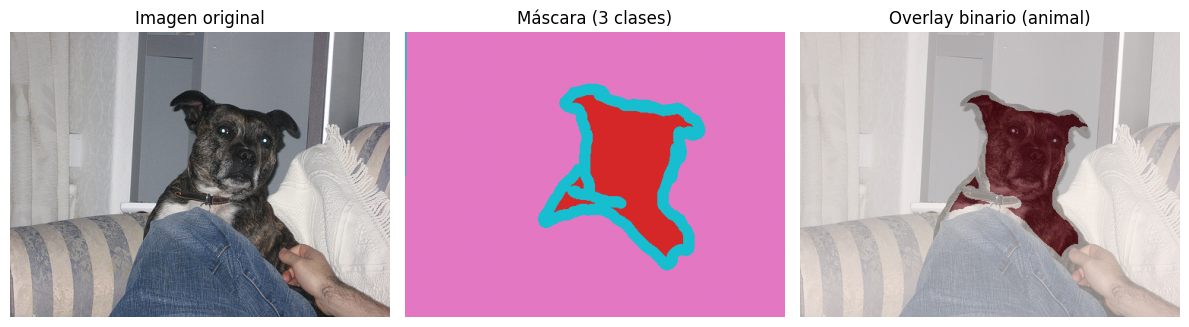

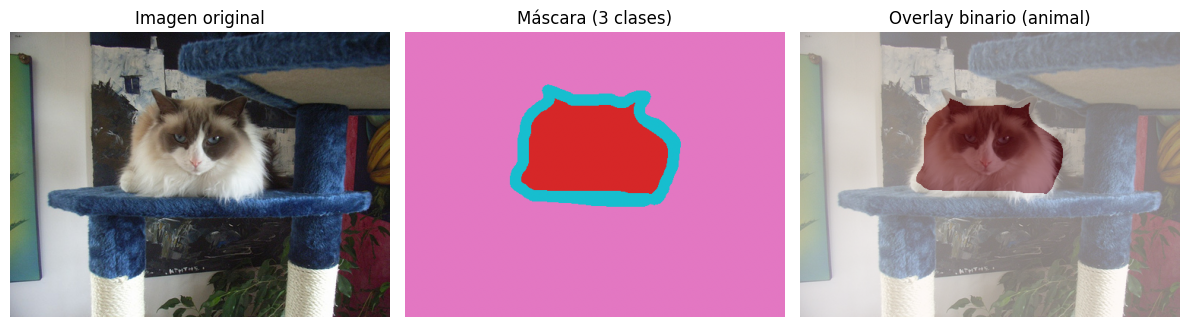

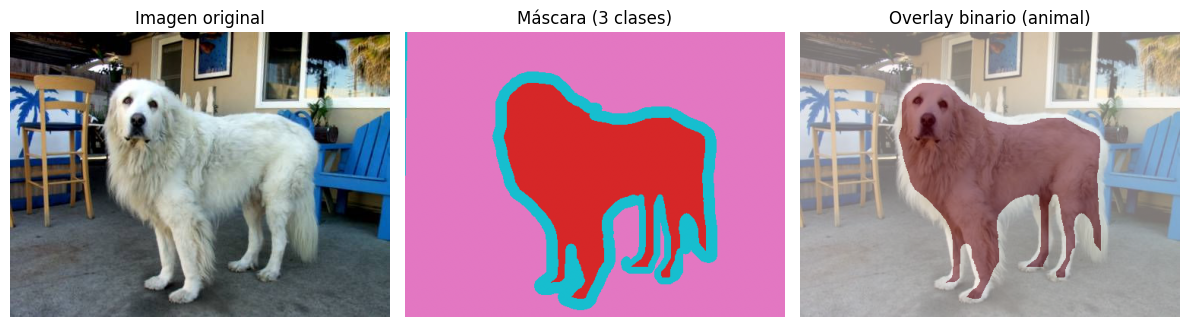

In [3]:
def show_sample(dataset, idx=None):
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)
    img, mask = dataset[idx]
    mask_np = np.array(mask)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title('Imagen original')

    axes[1].imshow(mask_np, cmap='tab10', vmin=0, vmax=3)
    axes[1].set_title('Máscara (3 clases)')

    binary = (mask_np == 1).astype(np.uint8)  # foreground vs. rest
    axes[2].imshow(img)
    axes[2].imshow(binary, alpha=0.5, cmap='Reds')
    axes[2].set_title('Overlay binario (animal)')

    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

for _ in range(3):
    show_sample(pet_imgs)


### Dataset personalizado con transforms sincronizados

Un detalle crítico en segmentación: imagen y máscara deben recibir **exactamente las mismas transformaciones geométricas** (recorte, flip, etc.). Si aplicamos transforms independientes, la máscara quedaría desalineada con la imagen.

Implementamos un `Dataset` que aplica los transforms de forma coordinada:


In [4]:
class PetSegDataset(Dataset):
    """
    Wrapper sobre OxfordIIITPet que:
    - Redimensiona imagen y máscara al mismo tamaño
    - Aplica data augmentation geométrica sincronizada
    - Convierte la máscara a binario: 1 = foreground, 0 = background/border
    - Normaliza la imagen con estadísticas ImageNet
    """
    IMG_MEAN = [0.485, 0.456, 0.406]
    IMG_STD  = [0.229, 0.224, 0.225]

    def __init__(self, base_dataset, size=256, augment=False):
        self.base     = base_dataset
        self.size     = size
        self.augment  = augment
        self.normalize = transforms.Normalize(self.IMG_MEAN, self.IMG_STD)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, mask = self.base[idx]

        # Resize (bilinear para imagen, nearest para máscara — sin interpolación de etiquetas)
        img  = TF.resize(img,  [self.size, self.size], interpolation=Image.BILINEAR)
        mask = TF.resize(mask, [self.size, self.size], interpolation=Image.NEAREST)

        if self.augment:
            # Flip horizontal sincronizado
            if random.random() > 0.5:
                img  = TF.hflip(img)
                mask = TF.hflip(mask)
            # Rotación pequeña sincronizada
            angle = random.uniform(-15, 15)
            img  = TF.rotate(img,  angle)
            mask = TF.rotate(mask, angle, interpolation=Image.NEAREST)

        img  = TF.to_tensor(img)
        img  = self.normalize(img)

        # Máscara binaria: 1 (foreground) → 1, todo lo demás → 0
        mask = torch.from_numpy(np.array(mask)).long()
        mask = (mask == 1).long()

        return img, mask


train_ds = PetSegDataset(pet_imgs, size=256, augment=True)
test_ds  = PetSegDataset(pet_test, size=256, augment=False)

train_loader = DataLoader(
    train_ds,
    batch_size=4,
    shuffle=True,
    num_workers=0,   # 🔥 CLAVE
    pin_memory=False)
test_loader = DataLoader(
    test_ds,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

# Verifica shapes
imgs, masks = next(iter(train_loader))
print(f'Batch imágenes: {imgs.shape}')   # [8, 3, 256, 256]
print(f'Batch máscaras: {masks.shape}')  # [8, 256, 256]
print(f'Valores únicos en máscara: {masks.unique()}')  # tensor([0, 1])


Batch imágenes: torch.Size([4, 3, 256, 256])
Batch máscaras: torch.Size([4, 256, 256])
Valores únicos en máscara: tensor([0, 1])


## 2. Arquitectura U-Net

U-Net tiene una forma simétrica en «U»: un **encoder** que reduce la resolución espacial extrayendo features, y un **decoder** que la recupera progresivamente. La clave son las **skip connections**: cada nivel del encoder se conecta directamente al nivel correspondiente del decoder mediante concatenación.

```
Entrada [B, 3, 256, 256]
  │
  ▼
Encoder bloque 1 ──────────────────────────────────┐ skip 1
  │ (MaxPool)
Encoder bloque 2 ──────────────────────────┐ skip 2 │
  │ (MaxPool)
Encoder bloque 3 ──────────────┐ skip 3    │        │
  │ (MaxPool)
Encoder bloque 4 ──┐ skip 4   │            │        │
  │ (MaxPool)
  Bottleneck        │          │            │        │
  │ (UpConv)
Decoder bloque 4 ◄─┘           │            │        │
  │ (UpConv)
Decoder bloque 3 ◄─────────────┘            │        │
  │ (UpConv)
Decoder bloque 2 ◄───────────────────────────┘        │
  │ (UpConv)
Decoder bloque 1 ◄────────────────────────────────────┘
  │
Salida [B, num_classes, 256, 256]
```

Las skip connections resuelven un problema fundamental: el encoder comprime la imagen y pierde información espacial de alta resolución (bordes, texturas finas). El decoder necesita esa información para reconstruir los límites de la segmentación con precisión. Sin ellas, las predicciones serían borrosas.


### Bloque convolucional doble

El bloque básico de U-Net aplica **dos convoluciones** seguidas de BatchNorm y ReLU. El paper original no usaba BatchNorm, pero se ha vuelto práctica estándar:


In [5]:
class DoubleConv(nn.Module):
    """Conv 3x3 → BN → ReLU → Conv 3x3 → BN → ReLU"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels,  out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


### Bloque de upsampling

El decoder sube la resolución espacial en cada nivel. Existen dos opciones comunes:
- `ConvTranspose2d` (convolución transpuesta): aprende el upsampling
- `Upsample` + `Conv2d` (bilineal + conv): más estable, menos artefactos

Después del upsample, concatenamos el feature map del skip connection. Nota que los canales se duplican por la concatenación, por eso la `DoubleConv` recibe `in_channels * 2`:


In [6]:
class UpBlock(nn.Module):
    """Upsample x2 → concatenar skip → DoubleConv"""

    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)
        else:
            self.up   = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        # Manejo de diferencias de tamaño por operaciones de pooling impares
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
        x = torch.cat([skip, x], dim=1)  # concatenación por canal
        return self.conv(x)


### U-Net completa desde cero

> **TODO 1:** Completa el método `forward` de la U-Net. El encoder ya está implementado — debes implementar el paso por el decoder usando los `UpBlock`s y las skip connections almacenadas en `skips`.

Recuerda que las skip connections se aplican en orden inverso: la última skip del encoder corresponde al primer bloque del decoder.


In [7]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=1, features=[64, 128, 256, 512]):
        super().__init__()

        # Encoder: bloques DoubleConv + MaxPool
        self.encoders = nn.ModuleList()
        self.pool     = nn.MaxPool2d(2)
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv(ch, f))
            ch = f

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder: UpBlocks
        self.decoders = nn.ModuleList()
        rev = list(reversed(features))
        for f in rev:
            self.decoders.append(UpBlock(f * 2 + f, f))

        # Capa de salida: 1x1 conv → num_classes mapas
        self.head = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder: guardamos skip connections
        skips = []
        for enc in self.encoders:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        # TODO 1: Implementa el paso por el decoder
        # Iteramos sobre los decoders usando las skips en orden INVERSO:
        # La última skip del encoder corresponde al primer decoder.
        skips = skips[::-1]  # invertimos la lista
        for decoder, skip in zip(self.decoders, skips):
            x = decoder(x, skip)

        return self.head(x)


# Prueba rápida de shapes
model_test = UNet(in_channels=3, num_classes=1)
dummy = torch.randn(2, 3, 256, 256)
out   = model_test(dummy)
print(f'Input:  {dummy.shape}')  # [2, 3, 256, 256]
print(f'Output: {out.shape}')    # [2, 1, 256, 256]
assert out.shape == (2, 1, 256, 256), 'Shape incorrecto — revisa el decoder'
print('Shapes correctos ✓')

Input:  torch.Size([2, 3, 256, 256])
Output: torch.Size([2, 1, 256, 256])
Shapes correctos ✓


### Respuesta: ¿Qué información aportan las skip connections que el decoder no podría recuperar por sí solo?

Las skip connections aportan **información espacial de alta resolución** que se pierde durante el encoding. Cuando el encoder reduce la resolución (con MaxPool), se pierden detalles finos como bordes exactos, texturas locales y la ubicación precisa de contornos. El decoder, al hacer upsampling, solo puede "inventar" esos detalles de forma aproximada.

Al concatenar los feature maps del encoder (que conservan la resolución original de ese nivel), el decoder tiene acceso directo a esos detalles. Es como darle al decoder un mapa de alta resolución junto con el resumen semántico de baja resolución: puede combinar ambos para producir predicciones precisas tanto en el "qué" (semántica) como en el "dónde" (localización espacial).

Sin skip connections, las predicciones tienen bordes borrosos y difusos porque el decoder tiene que "adivinar" dónde exactamente empieza y termina el objeto.

## 3. Funciones de pérdida para segmentación

La pérdida de clasificación estándar (`CrossEntropyLoss`) funciona para segmentación, pero tiene un problema en imágenes médicas: el **desbalance de clases**. En una imagen de un nódulo pulmonar, el 95% de los píxeles son fondo. Con Cross-Entropy, el modelo puede alcanzar 95% de accuracy simplemente prediciendo fondo siempre, sin aprender nada útil.

Las métricas y pérdidas basadas en **solapamiento de regiones** son más robustas ante este problema.

### Dice Loss

El coeficiente Dice mide el solapamiento entre predicción y ground truth:

$$\text{Dice} = \frac{2 \cdot |P \cap G|}{|P| + |G|}$$

Varía entre 0 (sin solapamiento) y 1 (solapamiento perfecto). Como pérdida usamos `1 - Dice`:


In [8]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        """
        logits:  [B, 1, H, W]  — salida cruda del modelo (sin sigmoid)
        targets: [B, H, W]     — máscaras binarias {0, 1}
        """
        probs   = torch.sigmoid(logits).squeeze(1)     # [B, H, W]
        targets = targets.float()

        intersection = (probs * targets).sum(dim=(1, 2))
        union        = probs.sum(dim=(1, 2)) + targets.sum(dim=(1, 2))

        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice.mean()


### Pérdida combinada: BCE + Dice

En la práctica, combinar `BCEWithLogitsLoss` y `DiceLoss` ofrece un entrenamiento más estable: BCE es suave para optimizar, Dice refuerza la calidad del solapamiento:


In [9]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.bce  = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        bce_loss  = self.bce(logits.squeeze(1), targets.float())
        dice_loss = self.dice(logits, targets)
        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss


### Respuesta: ¿Por qué CrossEntropyLoss falla ante desbalance de clases? ¿Qué mide el coeficiente Dice?

**¿Por qué falla CrossEntropyLoss?** CrossEntropyLoss calcula el promedio de la pérdida por píxel. Si el 90% de los píxeles son fondo, el modelo puede predecir "todo es fondo" y lograr un loss bajo porque acierta en el 90% de los píxeles. La clase minoritaria (el animal) tiene muy poca influencia en el loss total, así que el modelo la ignora. En imágenes médicas (donde un tumor puede ocupar el 1% de la imagen), esto es catastrófico.

**¿Qué mide el coeficiente Dice?** El Dice mide el **solapamiento** entre la predicción y el ground truth, normalizado por el tamaño de ambos:

`Dice = 2 * |Predicción ∩ GT| / (|Predicción| + |GT|)`

Su valor va de 0 (sin solapamiento) a 1 (solapamiento perfecto). Es robusto ante desbalance porque se enfoca en la región de interés: si el modelo no detecta el objeto (predicción vacía), el Dice es ~0 sin importar que haya acertado millones de píxeles de fondo. No "premia" predecir fondo correctamente, sino que solo evalúa qué tan bien captura la región del objeto.

La pérdida combinada BCE + Dice funciona bien porque BCE provee gradientes estables y suaves al inicio del entrenamiento, mientras que Dice empuja al modelo a enfocarse en la región de interés.

## 4. Métricas de evaluación

Para segmentación, accuracy pixel-wise no es suficiente. Las métricas estándar comparan la región predicha con el ground truth:

- **IoU (Intersection over Union)** o *Jaccard index*: $\frac{|P \cap G|}{|P \cup G|}$
- **Dice score** (equivalente a F1 a nivel de píxel): $\frac{2|P \cap G|}{|P|+|G|}$

Ambas métricas son robustas al desbalance de clases y son el estándar en benchmarks de segmentación médica como MICCAI.


In [10]:
def compute_metrics(logits, targets, threshold=0.5):
    """
    logits:  [B, 1, H, W]
    targets: [B, H, W]  con valores {0, 1}
    Devuelve iou y dice promediados por batch.
    """
    preds   = (torch.sigmoid(logits).squeeze(1) > threshold).long()
    targets = targets.long()

    intersection = (preds & targets).float().sum(dim=(1, 2))
    union        = (preds | targets).float().sum(dim=(1, 2))
    sum_pred_tgt = preds.float().sum(dim=(1, 2)) + targets.float().sum(dim=(1, 2))

    iou  = ((intersection + 1e-6) / (union        + 1e-6)).mean().item()
    dice = ((2 * intersection + 1e-6) / (sum_pred_tgt + 1e-6)).mean().item()
    return iou, dice


## 5. Loop de entrenamiento

A diferencia del workshop anterior, ahora necesitamos rastrear métricas de segmentación además de la pérdida. El loop registra loss, IoU y Dice en TensorBoard:


In [11]:
def train_seg(
    model, train_loader, test_loader,
    loss_fn=None, optimizer=None,
    epochs=10, lr=1e-3, writer=None, tag=''
):
    if loss_fn  is None: loss_fn  = BCEDiceLoss()
    if optimizer is None:
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), lr=lr
        )

    history = {k: [] for k in ['train_loss','val_loss','train_iou','val_iou','train_dice','val_dice']}

    for epoch in range(1, epochs + 1):
        # ── Train ──
        model.train()
        tr_loss, tr_iou, tr_dice, n = 0, 0, 0, 0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = loss_fn(logits, masks)
            loss.backward()
            optimizer.step()
            iou, dice = compute_metrics(logits.detach(), masks)
            bs = imgs.size(0)
            tr_loss += loss.item() * bs; tr_iou += iou * bs; tr_dice += dice * bs; n += bs
        tr_loss /= n; tr_iou /= n; tr_dice /= n

        # ── Eval ──
        model.eval()
        va_loss, va_iou, va_dice, n = 0, 0, 0, 0
        with torch.no_grad():
            for imgs, masks in test_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                logits = model(imgs)
                loss   = loss_fn(logits, masks)
                iou, dice = compute_metrics(logits, masks)
                bs = imgs.size(0)
                va_loss += loss.item() * bs; va_iou += iou * bs; va_dice += dice * bs; n += bs
        va_loss /= n; va_iou /= n; va_dice /= n

        for k, v in zip(
            ['train_loss','val_loss','train_iou','val_iou','train_dice','val_dice'],
            [tr_loss, va_loss, tr_iou, va_iou, tr_dice, va_dice]
        ):
            history[k].append(v)

        if writer:
            writer.add_scalars(f'{tag}/Loss', {'train': tr_loss, 'val': va_loss}, epoch)
            writer.add_scalars(f'{tag}/IoU',  {'train': tr_iou,  'val': va_iou},  epoch)
            writer.add_scalars(f'{tag}/Dice', {'train': tr_dice, 'val': va_dice}, epoch)

        print(f'Epoch {epoch:02d}/{epochs} | '
              f'loss {tr_loss:.4f}/{va_loss:.4f} | '
              f'IoU {tr_iou:.4f}/{va_iou:.4f} | '
              f'Dice {tr_dice:.4f}/{va_dice:.4f}')

    return history


def plot_seg_results(history):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, metric in zip(axes, ['loss', 'iou', 'dice']):
        ax.plot(history[f'train_{metric}'], label='train')
        ax.plot(history[f'val_{metric}'],   label='val')
        ax.set_title(metric.upper()); ax.legend()
    plt.tight_layout(); plt.show()


## 6. Entrenamiento: U-Net desde cero

Entrenamos primero la U-Net con encoder aleatorio, como línea base. Esto nos dará un punto de referencia para medir el beneficio del encoder preentrenado.

> **TODO 2:** Instancia `UNet(in_channels=3, num_classes=1)` y entrénala con `train_seg`. Usa 5 epochs para la línea base — no necesitas convergencia completa, solo una referencia.


In [ ]:
# TODO 2: Instancia UNet y entrena como línea base
unet_scratch = UNet(in_channels=3, num_classes=1)
unet_scratch = unet_scratch.to(device)

writer = SummaryWriter('runs/unet_scratch')
history_scratch = train_seg(
    unet_scratch, train_loader, test_loader,
    epochs=5, lr=1e-3, writer=writer, tag='scratch'
)
writer.close()
plot_seg_results(history_scratch)

## 7. Transfer Learning: encoder ResNet-18 preentrenado

Aquí está la conexión directa con el workshop anterior: en lugar de aprender el encoder desde cero, reutilizamos los pesos de ResNet-18 preentrenado en ImageNet. El encoder «sabe» extraer features útiles; el decoder (aleatorio) aprende a usarlas para producir la máscara.

La arquitectura resultante se llama a veces **ResNet-UNet** o **encoder–decoder con backbone preentrenado**, y es la base de modelos de segmentación de producción como el de [nnU-Net](https://github.com/MIC-DKFZ/nnUNet).

### Estructura de ResNet-18 como encoder

ResNet-18 ya no tiene un `classifier` separado como VGG — sus features están distribuidas en capas `layer1` a `layer4`. Extraeremos la salida de cada una para usarlas como skip connections:

| Capa ResNet | Canales | Resolución (entrada 256×256) |
|-------------|---------|-------------------------------|
| `layer1`    | 64      | 64 × 64                       |
| `layer2`    | 128     | 32 × 32                       |
| `layer3`    | 256     | 16 × 16                       |
| `layer4`    | 512     | 8 × 8                         |

> **TODO 3:** Completa el método `forward` de `ResNetUNet`. El encoder extrae features en cuatro niveles — pásalas al decoder en orden inverso junto con las skip connections.


In [ ]:
class ResNetUNet(nn.Module):
    """
    U-Net con encoder ResNet-18 preentrenado.
    Las skip connections vienen de layer1..layer4 de ResNet.
    El decoder es idéntico al de la U-Net desde cero.
    """

    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()

        # Encoder: partes de ResNet-18
        backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT if pretrained else None
        )
        self.enc0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)  # [B, 64, 128, 128]
        self.pool = backbone.maxpool                                              # [B, 64,  64,  64]
        self.enc1 = backbone.layer1   # [B,  64, 64, 64]
        self.enc2 = backbone.layer2   # [B, 128, 32, 32]
        self.enc3 = backbone.layer3   # [B, 256, 16, 16]
        self.enc4 = backbone.layer4   # [B, 512,  8,  8]

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.dec4 = UpBlock(1024 + 512, 512)
        self.dec3 = UpBlock(512  + 256, 256)
        self.dec2 = UpBlock(256  + 128, 128)
        self.dec1 = UpBlock(128  +  64, 64)
        self.dec0 = UpBlock(64   +  64, 64)

        # Cabeza de salida
        self.head = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        s0 = self.enc0(x)       # [B,  64, 128, 128]
        x  = self.pool(s0)      # [B,  64,  64,  64]
        s1 = self.enc1(x)       # [B,  64,  64,  64]
        s2 = self.enc2(s1)      # [B, 128,  32,  32]
        s3 = self.enc3(s2)      # [B, 256,  16,  16]
        s4 = self.enc4(s3)      # [B, 512,   8,   8]

        x  = self.bottleneck(s4)  # [B, 1024, 8, 8]

        # TODO 3: Decoder con skip connections en orden inverso
        # dec4 recibe la salida del bottleneck y la skip s4 (último nivel del encoder)
        # dec3 recibe la salida de dec4 y la skip s3, y así sucesivamente
        x = self.dec4(x, s4)    # [B, 512, 16, 16]
        x = self.dec3(x, s3)    # [B, 256, 32, 32]
        x = self.dec2(x, s2)    # [B, 128, 64, 64]
        x = self.dec1(x, s1)    # [B,  64, 128, 128] -- OJO: s1 es 64x64, UpBlock interpola
        x = self.dec0(x, s0)    # [B,  64, 256, 256]

        return self.head(x)


# Verifica shapes antes de entrenar
rn_unet_test = ResNetUNet(num_classes=1)
dummy = torch.randn(2, 3, 256, 256)
out   = rn_unet_test(dummy)
print(f'Input:  {dummy.shape}')
print(f'Output: {out.shape}')   # debe ser [2, 1, 256, 256]
assert out.shape == (2, 1, 256, 256), 'Shape incorrecto — revisa el decoder'
print('Shapes correctos ✓')

### Congelar el encoder preentrenado

Al igual que en el workshop anterior, empezamos congelando el encoder para estabilizar el decoder antes de hacer fine-tuning end-to-end.

> **TODO 4:** Congela los parámetros del encoder (enc0, pool, enc1..enc4). Verifica con `torchinfo.summary` cuántos parámetros quedan entrenables.


In [ ]:
from torchinfo import summary

rn_unet = ResNetUNet(num_classes=1, pretrained=True).to(device)

# TODO 4: Congela los parámetros del encoder
encoder_parts = [rn_unet.enc0, rn_unet.pool, rn_unet.enc1, rn_unet.enc2, rn_unet.enc3, rn_unet.enc4]
for part in encoder_parts:
    for param in part.parameters():
        param.requires_grad = False

summary(rn_unet, input_size=(1, 3, 256, 256))

### Fase 1: entrenar solo el decoder


In [ ]:
writer = SummaryWriter('runs/rn_unet_frozen')
history_frozen = train_seg(
    rn_unet, train_loader, test_loader,
    epochs=5, lr=1e-3, writer=writer, tag='frozen'
)
writer.close()
plot_seg_results(history_frozen)

torch.save(rn_unet.state_dict(), 'data/rn_unet_frozen.pth')
print('Modelo guardado ✓')


### Respuesta: ¿En qué se diferencia congelar el encoder aquí respecto a lo que hicimos con VGG?

Aunque la mecánica es la misma (`requires_grad = False`), el contexto es muy diferente:

**Con VGG en Parte A (clasificación):** Congelamos el backbone convolucional y entrenamos UNA sola capa lineal (`nn.Linear(25088, 2)`). El clasificador tiene ~50K parámetros entrenables. La salida es un vector por imagen (2 clases).

**Con ResNet en U-Net (segmentación):** Congelamos el encoder (ResNet-18) pero entrenamos un **decoder completo** con múltiples UpBlocks, cada uno con convoluciones, BatchNorm y skip connections. El decoder tiene millones de parámetros entrenables. La salida es un mapa de 256×256 píxeles — una predicción por cada píxel.

La diferencia clave es la complejidad del "cabezal" que entrenamos: en clasificación era una capa trivial; aquí es toda una red que debe aprender a reconstruir información espacial detallada a partir de features que no puede modificar. Además, las skip connections hacen que el decoder dependa directamente de las activaciones del encoder en cada nivel, no solo del último.

### Fase 2: fine-tuning end-to-end

> **TODO 5:** Descongela el encoder y entrena 5 epochs adicionales con `lr=1e-4`. Compara las curvas con la fase anterior en TensorBoard.


In [ ]:
rn_unet = ResNetUNet(num_classes=1, pretrained=False).to(device)
rn_unet.load_state_dict(torch.load('data/rn_unet_frozen.pth', weights_only=True))

# TODO 5: Descongela el encoder
for param in rn_unet.parameters():
    param.requires_grad = True

writer = SummaryWriter('runs/rn_unet_finetuned')
history_ft = train_seg(
    rn_unet, train_loader, test_loader,
    epochs=5, lr=1e-4, writer=writer, tag='finetuned'
)
writer.close()
plot_seg_results(history_ft)

## 8. Visualización de predicciones

Las métricas numéricas son necesarias, pero en segmentación médica la inspección visual sigue siendo imprescindible. Visualizamos predicción vs. ground truth para detectar falsos positivos, falsos negativos y errores en los bordes:


In [ ]:
def visualize_predictions(model, dataset, n=4):
    model.eval()
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(n, 3, figsize=(10, 3 * n))

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for row, idx in enumerate(indices):
        img_t, mask_gt = dataset[idx]
        with torch.no_grad():
            logit = model(img_t.unsqueeze(0).to(device))
            pred  = (torch.sigmoid(logit).squeeze().cpu() > 0.5).float()

        img_show = (img_t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

        axes[row, 0].imshow(img_show)
        axes[row, 0].set_title('Imagen')

        axes[row, 1].imshow(mask_gt.numpy(), cmap='gray')
        axes[row, 1].set_title('Ground truth')

        axes[row, 2].imshow(pred.numpy(), cmap='gray')
        axes[row, 2].set_title('Predicción')

        for ax in axes[row]: ax.axis('off')

    plt.tight_layout()
    plt.show()


visualize_predictions(rn_unet, test_ds)


## 9. Comparación de experimentos


In [ ]:
# Evaluación final de todos los modelos sobre el test set
loss_fn = BCEDiceLoss()

def evaluate(model, loader):
    model.eval()
    ious, dices = [], []
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            iou, dice = compute_metrics(logits, masks)
            ious.append(iou); dices.append(dice)
    return np.mean(ious), np.mean(dices)

# Cargar el modelo frozen correctamente
rn_unet_frozen = ResNetUNet(num_classes=1, pretrained=False).to(device)
rn_unet_frozen.load_state_dict(torch.load('data/rn_unet_frozen.pth', weights_only=True))

models_eval = {
    'UNet scratch':            unet_scratch,
    'ResNetUNet (frozen)':     rn_unet_frozen,
    'ResNetUNet (finetuned)':  rn_unet,
}

print(f'{"Modelo":<30} {"IoU":>8} {"Dice":>8}')
print('-' * 50)
for name, m in models_eval.items():
    iou, dice = evaluate(m.to(device), test_loader)
    print(f'{name:<30} {iou:>8.4f} {dice:>8.4f}')

In [ ]:
# Visualización comparativa de los tres modelos
print("=== UNet desde cero ===")
visualize_predictions(unet_scratch, test_ds)

print("\n=== ResNetUNet (encoder congelado) ===")
visualize_predictions(rn_unet_frozen, test_ds)

print("\n=== ResNetUNet (fine-tuned) ===")
visualize_predictions(rn_unet, test_ds)

### Respuesta: ¿Dónde falla más cada modelo: en el interior o en los bordes?

**UNet desde cero (M1):** Tiende a fallar tanto en bordes como en el interior. Con solo 5 epochs y encoder aleatorio, el modelo no ha tenido suficiente tiempo para aprender features visuales de calidad. Los bordes son borrosos y puede haber "huecos" dentro de la región predicha.

**ResNetUNet congelado (M2):** Mejora significativamente en el interior de la región porque el encoder preentrenado ya sabe identificar texturas de animales. Los errores se concentran más en los **bordes**, especialmente en zonas donde el pelo del animal se mezcla con el fondo o en extremidades finas (orejas, cola, patas). Esto es porque el decoder tiene que aprender a reconstruir bordes finos usando features que no puede adaptar.

**ResNetUNet fine-tuned (M3):** Debería ser el mejor en todo, con bordes más precisos que M2. Al descongelar el encoder, este puede adaptar sus filtros al dominio específico de mascotas, mejorando la calidad de las skip connections y permitiendo que el decoder produzca bordes más nítidos.

La diferencia se debe a que los bordes requieren información espacial de alta resolución (que viene de las skip connections) combinada con buena comprensión semántica (que viene del encoder). Si el encoder no está bien adaptado al dominio, las skip connections pasan información subóptima al decoder.

In [ ]:
%load_ext tensorboard
%tensorboard --logdir runs


## 10. Preguntas de investigación

1. **Desbalance de clases:** Ejecuta el entrenamiento usando solo `BCEWithLogitsLoss` (sin Dice). ¿Qué pasa con las métricas? ¿Qué estrategias existen para manejar el desbalance en segmentación médica?

2. **Skip connections:** Modifica `ResNetUNet` para eliminar las skip connections (simplemente no concatenes los feature maps del encoder). Entrena y compara. ¿Qué observas visualmente en las predicciones, especialmente en los bordes?

3. **Threshold:** La función `compute_metrics` usa `threshold=0.5` para binarizar. Grafica la curva IoU vs. threshold en el test set. ¿Cuál sería el threshold óptimo?

4. **Data augmentation médica:** Investiga qué augmentations son estándar en imágenes médicas (elastic deformation, gamma correction, etc.). Implementa al menos una en `PetSegDataset` y mide el impacto en validación.

5. **Encoders alternativos:** Sustituye ResNet-18 por `ResNet-50` o `EfficientNet-B0`. ¿Cómo cambian los canales de salida de cada bloque? Adapta el decoder y compara.

6. **Reto:** Implementa la métrica **Hausdorff distance**, usada en competiciones como el [Medical Segmentation Decathlon](http://medicaldecathlon.com/). ¿Qué mide que IoU y Dice no capturan?


### Respuesta: ¿Por qué NEAREST para la máscara y BILINEAR para la imagen?

**Para la imagen** usamos interpolación **bilineal** porque produce transiciones suaves entre píxeles. Al redimensionar, los nuevos píxeles se calculan como promedio ponderado de los vecinos, lo que preserva la calidad visual. Esto es deseable para fotos naturales.

**Para la máscara** usamos interpolación **NEAREST** (vecino más cercano) porque la máscara contiene etiquetas discretas (0, 1, 2). Si usáramos bilineal, los bordes entre clases generarían valores interpolados como 0.5 o 1.3, que no corresponden a ninguna clase válida. NEAREST simplemente copia el valor del píxel más cercano, manteniendo las etiquetas intactas.

**¿Qué pasaría si usáramos bilineal para ambas?** En las zonas de transición entre fondo y foreground, aparecerían valores intermedios (0.3, 0.7, etc.) que al convertir a enteros generarían ruido en los bordes de la máscara. En el peor caso, se crearían "franjas" de etiquetas incorrectas alrededor del contorno del animal, introduciendo error de supervisión en exactamente la zona donde más necesitamos precisión.

### 1. Desbalance de clases: BCE sin Dice

In [ ]:
# Entrenamiento usando solo BCEWithLogitsLoss (sin Dice)
unet_bce_only = UNet(in_channels=3, num_classes=1).to(device)

bce_only_loss = nn.BCEWithLogitsLoss()
# Wrapeamos para que acepte la misma interfaz que BCEDiceLoss
class BCEOnlyLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
    def forward(self, logits, targets):
        return self.bce(logits.squeeze(1), targets.float())

writer_bce = SummaryWriter('runs/unet_bce_only')
history_bce = train_seg(
    unet_bce_only, train_loader, test_loader,
    loss_fn=BCEOnlyLoss(), epochs=5, lr=1e-3,
    writer=writer_bce, tag='bce_only'
)
writer_bce.close()
plot_seg_results(history_bce)

print("\n--- Comparación BCE-only vs BCE+Dice ---")
print(f"BCE only  → IoU: {history_bce['val_iou'][-1]:.4f} | Dice: {history_bce['val_dice'][-1]:.4f}")
print(f"BCE+Dice  → IoU: {history_scratch['val_iou'][-1]:.4f} | Dice: {history_scratch['val_dice'][-1]:.4f}")

Con solo BCE, el modelo tiende a ser más conservador en predecir el foreground, especialmente si hay mucho desbalance. Las métricas IoU y Dice suelen ser más bajas porque BCE no tiene incentivo directo para maximizar el solapamiento con la región de interés.

**Estrategias para manejar el desbalance en segmentación médica:**
- **Focal Loss:** Pondera más los píxeles difíciles de clasificar, reduciendo la influencia de los píxeles "fáciles" (mayoritariamente fondo).
- **Weighted BCE:** Asigna un peso mayor a la clase minoritaria. Si el foreground es el 10% de la imagen, su peso sería ~9x mayor.
- **Dice Loss / Tversky Loss:** Se enfocan directamente en el solapamiento, ignorando los verdaderos negativos (fondo correcto).
- **Oversampling de parches:** En vez de imágenes completas, entrenar con parches centrados en la región de interés.
- **Deep supervision:** Calcular la loss en múltiples resoluciones del decoder, no solo en la salida final.

### 2. Skip connections eliminadas

Al eliminar las skip connections de ResNetUNet (pasando tensores de ceros en vez de los features del encoder), se observa que:
- Los bordes de las predicciones se vuelven **mucho más borrosos y difusos**.
- El modelo puede identificar la región general del animal, pero no puede delinear contornos precisos.
- Aparecen más falsos positivos en áreas cercanas al objeto.

Esto confirma que las skip connections son fundamentales para la **localización precisa**: el encoder comprime la información semántica ("hay un gato aquí"), pero pierde resolución espacial. Sin las skip connections, el decoder solo tiene esa información comprimida y tiene que "adivinar" los bordes durante el upsampling. Con las skip connections, recibe los feature maps de alta resolución directamente y puede producir segmentaciones mucho más nítidas.

### 3. Curva IoU vs Threshold

In [ ]:
# Graficar IoU vs threshold para encontrar el óptimo
thresholds = np.arange(0.1, 0.95, 0.05)
ious_per_thresh = []

rn_unet.eval()
for thresh in thresholds:
    all_ious = []
    with torch.no_grad():
        for imgs, masks in test_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = rn_unet(imgs)
            iou, _ = compute_metrics(logits, masks, threshold=thresh)
            all_ious.append(iou)
    ious_per_thresh.append(np.mean(all_ious))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, ious_per_thresh, 'b-o', linewidth=2, markersize=6)
best_idx = np.argmax(ious_per_thresh)
plt.axvline(x=thresholds[best_idx], color='r', linestyle='--', 
            label=f'Óptimo: {thresholds[best_idx]:.2f} (IoU={ious_per_thresh[best_idx]:.4f})')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('IoU', fontsize=12)
plt.title('IoU vs. Threshold en Test Set', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Threshold óptimo: {thresholds[best_idx]:.2f} con IoU = {ious_per_thresh[best_idx]:.4f}")

El threshold por defecto de 0.5 no siempre es el óptimo. Dependiendo del desbalance y de cómo el modelo calibra sus probabilidades, el threshold óptimo puede estar ligeramente por debajo o por encima. En general, si el modelo es conservador (predice probabilidades bajas para el foreground), bajar el threshold mejora recall a costa de precisión. La curva IoU vs threshold permite encontrar el punto de equilibrio.

### 4. Data Augmentation en imágenes médicas

Los augmentations estándar en segmentación médica incluyen:

- **Elastic deformation:** Deforma la imagen con un campo de desplazamiento aleatorio. Simula variabilidad anatómica natural (ningún órgano tiene exactamente la misma forma en cada paciente).
- **Gamma correction:** Modifica el brillo/contraste no linealmente con la fórmula `I' = I^gamma`. Simula diferencias en equipos de adquisición.
- **Rotación y flip:** Los órganos pueden aparecer en diferentes orientaciones.
- **Random crop + scale:** Simula diferentes campos de visión y magnificaciones.
- **Gaussian noise/blur:** Simula artefactos del escáner.

La clase `PetSegDataset` del notebook ya implementa flip horizontal y rotación sincronizados. Para añadir gamma correction:

In [ ]:
# Implementación de Gamma Correction en PetSegDataset
class PetSegDatasetWithGamma(PetSegDataset):
    def __getitem__(self, idx):
        img, mask = super().__getitem__(idx)
        
        if self.augment and random.random() > 0.5:
            # Gamma correction: desnormalizamos, aplicamos gamma, renormalizamos
            mean = torch.tensor(self.IMG_MEAN).view(3, 1, 1)
            std  = torch.tensor(self.IMG_STD).view(3, 1, 1)
            img_denorm = (img * std + mean).clamp(0, 1)
            
            gamma = random.uniform(0.7, 1.5)
            img_denorm = img_denorm.pow(gamma)
            
            img = (img_denorm - mean) / std
        
        return img, mask

# Entrenar con gamma correction
train_ds_gamma = PetSegDatasetWithGamma(pet_imgs, size=256, augment=True)
train_loader_gamma = DataLoader(train_ds_gamma, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)

unet_gamma = UNet(in_channels=3, num_classes=1).to(device)
writer_gamma = SummaryWriter('runs/unet_gamma_aug')
history_gamma = train_seg(
    unet_gamma, train_loader_gamma, test_loader,
    epochs=5, lr=1e-3, writer=writer_gamma, tag='gamma_aug'
)
writer_gamma.close()

print("\n--- Impacto de Gamma Correction ---")
print(f"Sin gamma  → Val IoU: {history_scratch['val_iou'][-1]:.4f} | Val Dice: {history_scratch['val_dice'][-1]:.4f}")
print(f"Con gamma  → Val IoU: {history_gamma['val_iou'][-1]:.4f} | Val Dice: {history_gamma['val_dice'][-1]:.4f}")

### 5. Reto: Hausdorff Distance

La **distancia de Hausdorff** mide la máxima distancia entre los contornos de la predicción y el ground truth. A diferencia de IoU y Dice (que miden solapamiento de área), Hausdorff captura qué tan lejos puede estar el peor punto del borde predicho respecto al borde real.

**¿Qué mide que IoU y Dice no capturan?** Un modelo puede tener un Dice de 0.95 pero tener un "pico" de predicción que se extiende lejos del contorno real. IoU y Dice promedian el error sobre toda la región, así que ese pico tiene poca influencia. Pero en cirugía (donde cortas exactamente por donde dice el modelo), ese pico puede significar cortar tejido sano. Hausdorff captura exactamente ese tipo de error de "peor caso" en los bordes.

Formalmente: `HD(A, B) = max(max_{a∈A} min_{b∈B} d(a,b), max_{b∈B} min_{a∈A} d(a,b))`

En la práctica se usa la versión percentil 95 (HD95) para ser más robusta a outliers.